**DSCI 8950 - Data Science** **Capstone**

**Mid-Semester Progress: ML Applications to Project**

**Machine Learning Analysis of Socioeconomic Factors Influencing School Absenteeism - NILESH PURNEKAR**

**Step 1: Introduction**

In the earlier stage of this project, I conducted exploratory data analysis (EDA) to understand the structure of the dataset and examine patterns related to school absenteeism. During that stage, I focused on visualizing the data, summarizing distributions, and exploring relationships between absenteeism and school-level socioeconomic indicators. The EDA suggested that schools with higher percentages of students eligible for Free and Reduced Lunch (FRL) often had higher absenteeism rates, and that absenteeism also varied across different school types.

However, EDA mainly helps identify patterns and possible relationships in the data. In this stage of the project, the goal is to move beyond description and apply machine learning methods to examine whether socioeconomic and school-level factors can help predict absenteeism rates. Chronic absenteeism is an important issue because it can affect student learning, academic performance, and overall school outcomes. Socioeconomic factors are relevant because they may reflect broader challenges that influence student attendance. Therefore, this analysis uses regression-based machine learning models to study how these factors relate to absenteeism and to determine which model best fits the data.

**Step 2: Loading the Dataset**

In [ ]:
import pandas as pd

df = pd.read_excel("Step13_FRL_vs_Chronic_Merged_SchoolLevel.xlsx")

df.head()

,FY,COUNTY,CODISTSCH,SCHOOLNAME,SCHOOLTYPE,GRADE,ENROLLED,FREEREDUCED,PERCENT,WARNING,...,DISTRICT CODE,DISTRICT NAME,SCHOOL CODE,SCHOOL NAME,MEMBERSHIP,STUDENTS WITH MORE THAN 10 DAYS TOTAL ABSENCES,STUDENTS WITH MORE THAN 15 DAYS TOTAL ABSENCES,STUDENTS WITH MORE THAN 20 DAYS TOTAL ABSENCES,CHRONIC\nABSENT,% STUDENTS WITH MORE THAN 20 DAYS TOTAL ABSENCES
0,2020-2021,BUFFALO,100002001,GIBBON HIGH SCHOOL,SECONDARY,2026-07-12 00:00:00,241,134,0.5560,NaN,...,10-0002-000,GIBBON PUBLIC SCHOOLS,10-0002-001,GIBBON HIGH SCHOOL,241,144,86,60,88,0.248963
1,2020-2021,BUFFALO,100002002,GIBBON ELEMENTARY SCHOOL,ELEMENTARY,PK-06,329,183,0.5562,NaN,...,10-0002-000,GIBBON PUBLIC SCHOOLS,10-0002-002,GIBBON ELEMENTARY SCHOOL,298,90,53,31,56,0.104027
2,2020-2021,BUFFALO,100007003,BRYANT ELEMENTARY SCHOOL,ELEMENTARY,K -05,235,180,0.7660,NaN,...,10-0007-000,KEARNEY PUBLIC SCHOOLS,10-0007-003,BRYANT ELEMENTARY SCHOOL,226,78,38,21,40,0.09292
3,2020-2021,BUFFALO,100007004,EMERSON ELEMENTARY SCHOOL,ELEMENTARY,K -05,206,153,0.7427,NaN,...,10-0007-000,KEARNEY PUBLIC SCHOOLS,10-0007-004,EMERSON ELEMENTARY SCHOOL,198,48,25,10,27,0.050505
4,2020-2021,BUFFALO,100007005,KENWOOD ELEMENTARY SCHOOL,ELEMENTARY,K -05,390,147,0.3769,NaN,...,10-0007-000,KEARNEY PUBLIC SCHOOLS,10-0007-005,KENWOOD ELEMENTARY SCHOOL,374,57,31,19,34,0.050802


**Explanation for Step 2**

The dataset used in this step was taken from the previous EDA assignment. During the EDA stage, different school-level datasets related to absenteeism and Free and Reduced Lunch (FRL) were cleaned and merged to create a final working dataset for analysis. That final merged file was saved as **Step13_FRL_vs_Chronic_Merged_SchoolLevel.xlsx, which came from Step 13 of the earlier EDA work.**

In this step, that file is loaded into Google Colab so it can be used for the machine learning part of the project. This is important because the current assignment specifically asks us to use the preprocessed data from the EDA stage. By loading this dataset, we are continuing from the previous assignment instead of starting over with the raw files. This dataset contains the school-level variables needed for regression, including absenteeism-related measures and socioeconomic indicators such as FRL percentage.

**Step 3: Inspecting the Dataset**

This step helps us understand:

**number of rows**

**column names**

**data types**

**missing values**

Before doing regression we must understand the dataset structure.

In [ ]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637 entries, 0 to 636
Data columns (total 24 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   FY                                                637 non-null    object 
 1   COUNTY                                            637 non-null    object 
 2   CODISTSCH                                         637 non-null    int64  
 3   SCHOOLNAME                                        637 non-null    object 
 4   SCHOOLTYPE                                        637 non-null    object 
 5   GRADE                                             637 non-null    object 
 6   ENROLLED                                          637 non-null    int64  
 7   FREEREDUCED                                       637 non-null    int64  
 8   PERCENT                                           637 non-null    float64
 9   WARNING              

,CODISTSCH,ENROLLED,FREEREDUCED,PERCENT,WARNING,FRL_PERCENT,MERGE_KEY,MEMBERSHIP
count,6.370000e+02,637.000000,637.000000,637.000000,0.0,637.000000,6.370000e+02,637.000000
mean,4.614281e+08,265.962323,121.627943,0.456314,NaN,45.631366,4.614281e+08,248.084772
std,2.346397e+08,162.179966,113.724419,0.212810,NaN,21.281013,2.346397e+08,154.072511
min,1.000020e+08,17.000000,12.000000,0.041800,NaN,4.180000,1.000020e+08,3.000000
25%,2.800011e+08,133.000000,50.000000,0.304000,NaN,30.400000,2.800011e+08,123.000000
50%,4.400700e+08,237.000000,79.000000,0.434800,NaN,43.480000,4.400700e+08,218.000000
75%,6.605010e+08,368.000000,159.000000,0.582300,NaN,58.230000,6.605010e+08,344.000000
max,9.300960e+08,889.000000,760.000000,0.989900,NaN,98.990000,9.300960e+08,844.000000


**Explanation for Step 3**

In this step, the structure of the dataset is examined before proceeding with the modeling process. The info() function is used to display information about the dataset, including the number of rows, column names, data types, and whether there are any missing values. This helps ensure that the variables are stored in the correct format and allows us to identify potential data quality issues.

The describe() function is also used to generate summary statistics for the numerical variables in the dataset. These statistics include the mean, minimum, maximum, and standard deviation of each variable. Examining these values helps provide a better understanding of the distribution and scale of the variables that will later be used in the regression models.

**Step 4: Selecting Target and Predictor Variables**

In [ ]:
target = "% STUDENTS WITH MORE THAN 20 DAYS TOTAL ABSENCES"

features = ["FRL_PERCENT", "ENROLLED", "MEMBERSHIP", "PERCENT"]

X = df[features]
y = df[target]

X.head()

,FRL_PERCENT,ENROLLED,MEMBERSHIP,PERCENT
0,55.60,241,241,0.5560
1,55.62,329,298,0.5562
2,76.60,235,226,0.7660
3,74.27,206,198,0.7427
4,37.69,390,374,0.3769


**Explanation for Step 4**

In this step, the target variable and predictor variables are defined for the regression analysis. The target variable represents the percentage of students with more than 20 total absences, which serves as the measure of chronic absenteeism in this dataset.

The predictor variables include socioeconomic and school-level indicators such as the percentage of students eligible for Free and Reduced Lunch (FRL), total enrollment, membership, and other related measures. These variables were selected because they may help explain differences in absenteeism rates across schools. By separating the dataset into predictor variables (X) and the target variable (y), the data is prepared for building machine learning regression models.

**Step 5: Initial Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((509, 4), (128, 4))

**Explanation for Step 5**

In this step, the dataset is divided into training and testing sets using the train_test_split() function from the scikit-learn library. **This step is performed after selecting the predictor variables** and the target variable in the previous step, and it prepares the data for building machine learning models.

This step is necessary in machine learning because it allows the model to be trained on one portion of the data and evaluated on a separate portion that was not used during training. This helps provide a more realistic assessment of how well the model can perform on new, unseen data.

In this analysis, the parameter test_size = 0.2 is used, which means that 20% of the dataset is reserved for testing and the remaining 80% is used for training the model. The training data is used to build the regression models, while the testing data is used later to evaluate the model’s performance. The random_state = 42 parameter ensures that the data is shuffled in a consistent way before splitting, so that the same training and testing sets are generated each time the code is run. This makes the results reproducible and easier to verify.



**Step 6: Cleaning the Target Variable**

In [ ]:
y = pd.to_numeric(y, errors='coerce')

df_clean = pd.concat([X, y], axis=1).dropna()

X = df_clean[features]
y = df_clean[target]

**Explanation for Step 6**

In this step, the target variable is cleaned to ensure that it contains only numeric values before building the regression model. When the dataset was inspected, it was observed that some entries in the absenteeism column were represented by symbols such as "*". These values cannot be interpreted as numbers by machine learning algorithms.

To address this issue, the to_numeric() function is used to convert the target variable into numeric format. The parameter errors='coerce' converts any non-numeric values into missing values (NaN). After this conversion, rows containing missing values are removed from the dataset using the dropna() function. This ensures that the dataset used for modeling contains only valid numerical observations and prevents errors during model training.

**Step 7: Splitting the Data into Training and Testing Sets after Data Cleaning**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((264, 4), (67, 4))

**Explanation for Step 7**

In this step, the dataset is divided into training and testing sets again using the train_test_split() function from the scikit-learn library. **This step is performed after cleaning the target variable in the previous step**, where non-numeric values were converted and invalid observations were removed from the dataset.

Splitting the dataset again ensures that the training and testing sets are created using the cleaned dataset, which contains only valid numerical values. Splitting the dataset is an important step in machine learning because it allows the model to be trained on one portion of the data and evaluated on another portion that was not used during training.

In this analysis, the parameter test_size = 0.2 specifies that 20% of the dataset will be used as the testing set, while the remaining 80% will be used as the training set. The training data is used to build the regression model, and the testing data is used later to evaluate how well the model performs on unseen data. The random_state = 42 parameter ensures that the data is shuffled in a consistent way before splitting, so that the same training and testing sets are generated each time the code is executed.

**Step 8: Building the Linear Regression Model**

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred[:5]

array([0.2258224 , 0.10150622, 0.11214965, 0.07489531, 0.10752644])

**Explanation for Step 8**

In this step, a Linear Regression model is built using the training dataset. Linear regression is a commonly used method for predicting continuous variables and is often used as a baseline model in regression analysis. The goal of the model is to estimate the relationship between the predictor variables and the target variable, which in this case is the percentage of students with more than 20 days of total absences.

The fit() function is used to train the model using the training data, where the model learns how the predictor variables relate to the target variable. After the model is trained, the predict() function is used to generate predictions for the testing dataset. These predictions represent the model's estimated absenteeism rates based on the predictor variables.

**Step 9: Evaluating the Linear Regression Model**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(0.05613478983006684, np.float64(0.0690080812260804), 0.15588624741687906)

**Explanation for Step 9**

In this step, the performance of the Linear Regression model is evaluated using several commonly used regression evaluation metrics. These metrics help measure how well the model predicts absenteeism values compared to the actual observed values in the testing dataset.

**The Mean Absolute Error(MAE)** measures the average absolute difference between the predicted and actual values. A smaller MAE indicates that the predictions are closer to the true values. **The Root Mean Squared Error(RMSE)** measures the square root of the average squared differences between predicted and actual values. RMSE gives more weight to larger errors and helps identify how far predictions deviate from the actual values. The **R-squared (R²)** score indicates how much of the variation in the target variable is explained by the predictor variables in the model. An R² value closer to 1 indicates better model performance.

These metrics provide a quantitative way to assess how well the regression model performs and will later be used to compare this model with other machine learning models.

**Step 10: Building a Decision Tree Regression Model**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

y_pred_tree[:5]

array([0.28846154, 0.12711864, 0.11019284, 0.04932735, 0.08370703])

**Explanation for Step 10**

In this step, a Decision Tree Regression model is built to predict absenteeism rates. Decision trees are a type of machine learning model that split the dataset into smaller subsets based on feature values. The model learns a series of decision rules that help predict the target variable.

Unlike linear regression, which assumes a linear relationship between predictors and the target variable, decision trees can capture more complex and nonlinear relationships in the data. This makes them useful when the relationship between variables is not strictly linear. The model is trained using the training dataset and then used to generate predictions for the testing dataset.

**Step 11: Evaluating the Decision Tree Regression Model**

In [ ]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

mae_tree, rmse_tree, r2_tree

(0.06534490663374233, np.float64(0.08506009223980587), -0.2824864068068791)

**Explanation for Step 11**

In this step, the performance of the Decision Tree Regression model is evaluated using the same evaluation metrics used for the Linear Regression model as above. These metrics include Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R-squared (R²) score. Using the same metrics allows us to compare how well different models perform on the same dataset.

The Mean Absolute Error measures the average difference between the predicted absenteeism values and the actual values in the testing dataset. The Root Mean Squared Error measures the square root of the average squared prediction errors, which helps capture larger prediction errors more strongly. The R-squared score indicates how much of the variation in absenteeism is explained by the model. By calculating these metrics, we can evaluate how accurately the Decision Tree model predicts absenteeism rates.

**Step 12: Building a Random Forest Regression Model**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

y_pred_rf[:5]

array([0.24196216, 0.12820856, 0.07588453, 0.04851356, 0.12327008])

**Explanation for Step 12**

In this step, a Random Forest Regression model is built to predict absenteeism rates. Random Forest is an ensemble learning method that constructs multiple decision trees during training and combines their predictions to produce a final result. This approach helps improve prediction accuracy and reduce the risk of overfitting that can occur with a single decision tree.

The model is trained using the training dataset and then used to generate predictions for the testing dataset. Because Random Forest combines the predictions of many trees, it can capture more complex relationships between the predictor variables and the target variable. This makes it a useful model to compare with simpler models such as Linear Regression and Decision Tree Regression.

**Step 13: Evaluating the Random Forest Regression Model**

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf

(0.050165728329575915, np.float64(0.06606421107626298), 0.22636950893552343)

**Explanation for Step 13**

In this step, the performance of the Random Forest Regression model is evaluated using the same evaluation metrics used for the previous models. These metrics include Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R-squared (R²) score. Using the same metrics across different models allows for a fair comparison of how well each model predicts absenteeism rates.

The Mean Absolute Error measures the average difference between the predicted absenteeism values and the actual values in the testing dataset. The Root Mean Squared Error measures the square root of the average squared differences between predicted and actual values, giving more weight to larger prediction errors. The R-squared score indicates how much of the variation in absenteeism is explained by the model. Evaluating the Random Forest model using these metrics helps determine whether it performs better than the previous models.

**Step 14: Applying Cross-Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring="r2")

cv_scores

array([ 0.22545379,  0.19690456, -0.53720095,  0.24103398,  0.0568754 ])

**Explanation for Step 14**

In this step, cross-validation is used to further evaluate the performance of the model. Instead of relying on a single train-test split, cross-validation divides the dataset into multiple subsets called folds. The model is trained on several folds and tested on the remaining fold, and this process is repeated multiple times.

In this analysis, 5-fold cross-validation is used. This means the dataset is divided into five parts, and the model is trained and tested five times using different subsets of the data. The cross_val_score() function calculates the R² score for each fold, providing multiple estimates of model performance. Cross-validation helps provide a more reliable evaluation of the model because it uses different portions of the dataset for training and testing.

**Step 15: Hyperparameter Tuning for Random Forest**

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

grid_search.best_params_

{'max_depth': 5, 'n_estimators': 200}

**Explanation for Step 15**

In this step, hyperparameter tuning is performed to improve the performance of the Random Forest model. Machine learning models often contain parameters that control how the model learns from the data. These parameters are called hyperparameters, and selecting appropriate values for them can significantly affect the model’s performance.

To identify better hyperparameter values, the **GridSearchCV method** is used. Grid search systematically tests multiple combinations of hyperparameter values and evaluates their performance using cross-validation. In this analysis, different values for the number of trees (n_estimators) and the maximum depth of each tree (max_depth) are tested to determine which combination provides the best predictive performance based on the R² score.

Hyperparameter tuning is applied specifically to the Random Forest model because it contains several parameters that can strongly influence how the model learns patterns in the data. Compared to simpler models such as Linear Regression, Random Forest relies on multiple decision trees and therefore benefits more from tuning these parameters. By adjusting these settings, the model can achieve better predictive accuracy and reduce the risk of overfitting.

**Step 16: Training the Tuned Random Forest Model**

In [ ]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)

y_pred_best = best_rf.predict(X_test)

y_pred_best[:5]

array([0.22917608, 0.09766532, 0.09468763, 0.04968584, 0.13023487])

**Explanation for Step 16**

After identifying the best hyperparameter combination using grid search, the tuned Random Forest model is used to generate predictions. The best_estimator_ attribute of the grid search object returns the model that achieved the best performance during the tuning process.

This optimized model is then trained using the training dataset and used to predict absenteeism values for the testing dataset. Using a tuned model can often improve prediction accuracy because the hyperparameters are selected based on the model’s performance during cross-validation.

**Step 17: Evaluating the Tuned Random Forest Model**

In [ ]:
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

mae_best, rmse_best, r2_best

(0.04884487945998656, np.float64(0.06413111833390768), 0.2709812494124252)

**Explanation for Step 17**

In this step, the tuned Random Forest model is evaluated using the same evaluation metrics used earlier in the analysis. These metrics include Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R-squared (R²) score. Using the same evaluation metrics allows for consistent comparison with the previous models.

The results from this step help determine whether hyperparameter tuning improved the performance of the Random Forest model. If the tuned model produces lower error values and a higher R² score, it indicates that tuning the model helped improve its predictive accuracy.

**Step 18: Comparing Model Performance**

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Tuned Random Forest"],
    "MAE": [mae, mae_tree, mae_rf, mae_best],
    "RMSE": [rmse, rmse_tree, rmse_rf, rmse_best],
    "R2": [r2, r2_tree, r2_rf, r2_best]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.056135,0.069008,0.155886
1,Decision Tree,0.065345,0.085060,-0.282486
2,Random Forest,0.050166,0.066064,0.226370
3,Tuned Random Forest,0.048845,0.064131,0.270981


**Explanation for Step 18**

In this step, the performance of all models used in the analysis is compared using a summary table. The table includes the evaluation metrics for Linear Regression, Decision Tree Regression, Random Forest Regression, and the tuned Random Forest model. By presenting the results in a single table, it becomes easier to observe how each model performs relative to the others.

Comparing these models allows us to determine which modeling approach provides the most accurate predictions for absenteeism rates. The model with the lowest error values and the highest R² score can be considered the best performing model among those tested.

**Step 19: Visual Comparison of Model Performance**

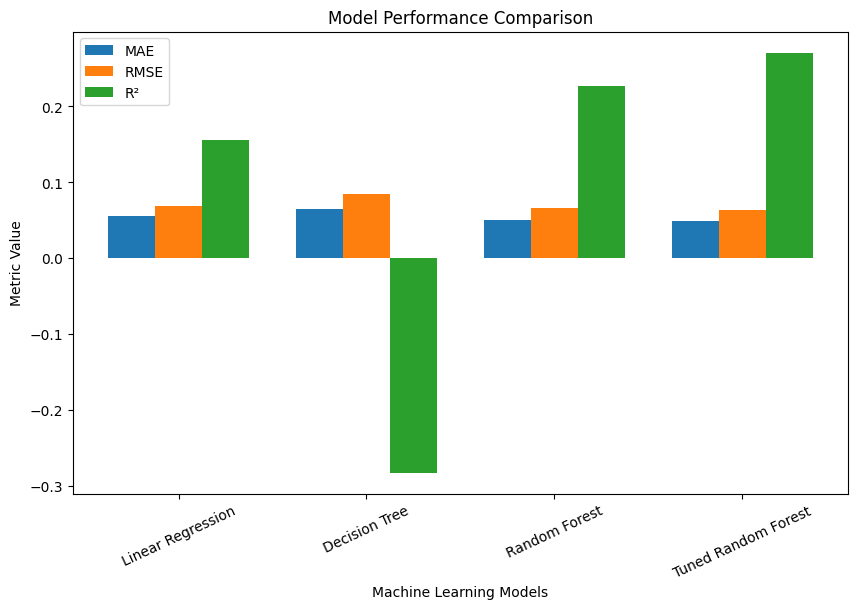

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Linear Regression", "Decision Tree", "Random Forest", "Tuned Random Forest"]

mae_scores = [mae, mae_tree, mae_rf, mae_best]
rmse_scores = [rmse, rmse_tree, rmse_rf, rmse_best]
r2_scores = [r2, r2_tree, r2_rf, r2_best]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, mae_scores, width, label="MAE")
plt.bar(x, rmse_scores, width, label="RMSE")
plt.bar(x + width, r2_scores, width, label="R²")

plt.xticks(x, models, rotation=25)
plt.xlabel("Machine Learning Models")
plt.ylabel("Metric Value")
plt.title("Model Performance Comparison")

plt.legend()
plt.show()

**Explanation for Step 19**

In this step, a grouped bar chart is created to visually compare the performance of the different machine learning models used in the analysis. The chart displays three evaluation metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R-squared (R²) score for each model.

Using multiple metrics in a single visualization makes it easier to compare the strengths and weaknesses of each model. For MAE and RMSE, lower values indicate better predictive performance because they represent smaller prediction errors. For the R² score, higher values indicate better performance because they show that the model explains more of the variation in absenteeism rates.

By observing the chart, it becomes easier to identify which model performs best overall. In this case, the **Tuned Random Forest model shows the strongest performance**, with higher R² and relatively lower error values compared to the other models. This suggests that the tuned Random Forest model provides the most accurate predictions for absenteeism rates in this dataset.

**Step 20: Interpretation of Model Comparison Results**


Based on the comparison of model performance in Step 19, the **Tuned Random Forest model achieved the best predictive performance among the models tested**. The tuned Random Forest produced an R² score of approximately 0.27, which was higher than the scores obtained from the other models. The Random Forest model without tuning achieved an R² score of about 0.23, while the Linear Regression model produced an R² score of approximately 0.15. In contrast, the Decision Tree model performed poorly and resulted in a negative R² score (approximately -0.28), indicating that it did not effectively capture the relationship between the predictor variables and absenteeism.

**The tuned Random Forest model improved the R² score from 0.226 to 0.271, showing that hyperparameter tuning helped improve model performance.**

These results suggest that ensemble learning approaches such as Random Forest are better suited for this dataset. Because Random Forest combines multiple decision trees, it can capture more complex relationships and interactions between variables compared to simpler models such as Linear Regression or a single Decision Tree.

The results also indicate that socioeconomic indicators such as **the percentage of students receiving Free and Reduced Lunch (FRL) may be associated with differences in absenteeism rates across schools**. Schools with higher FRL percentages may experience different attendance patterns compared to schools with lower FRL percentages. In addition, school-level characteristics such as enrollment and membership appear to contribute to predicting absenteeism rates across schools.

However, it is important to interpret these findings as **associations rather than direct causal relationships**. While the models show that socioeconomic and school-level factors help explain variations in absenteeism, additional research would be required to determine the underlying causes of these patterns.

**Step 21 (Optional): Feature Importance Analysis**

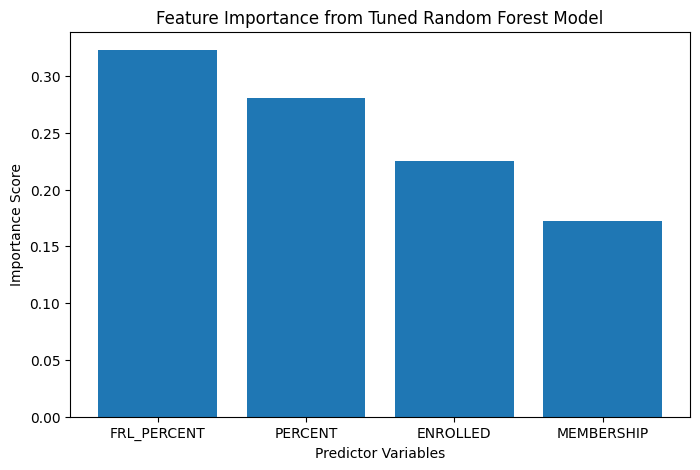

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])

plt.xlabel("Predictor Variables")
plt.ylabel("Importance Score")
plt.title("Feature Importance from Tuned Random Forest Model")

plt.show()

**Explanation for Step 21**

In this optional step, feature importance analysis is performed using the tuned Random Forest model. Random Forest models provide a measure of how important each predictor variable is in contributing to the model’s predictions. The importance score indicates how much each variable contributes to reducing prediction error in the model.

By extracting the feature importance values from the tuned Random Forest model, it becomes possible to identify which variables had the greatest influence on predicting absenteeism rates. The results are visualized using a bar chart to allow for easier comparison of the relative importance of each predictor variable.

This analysis provides additional insight into which socioeconomic or school-level variables contribute most strongly to predicting absenteeism. For example, if the FRL percentage shows a higher importance score, it suggests that socioeconomic conditions related to student poverty may play an important role in explaining differences in absenteeism across schools. However, these importance values represent predictive influence rather than causal relationships.

**Step 22: Conclusion**


In this analysis, several machine learning models were applied to examine whether socioeconomic and school-level factors could help predict absenteeism rates across schools. The models tested included Linear Regression, Decision Tree Regression, Random Forest Regression, and a tuned Random Forest model. The performance of these models was evaluated using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R² score.

Based on the results, the tuned Random Forest model achieved the best predictive performance, indicating that ensemble models may be better suited for capturing the relationships between socioeconomic indicators and absenteeism patterns. The analysis suggests that variables such as the percentage of students receiving Free and Reduced Lunch (FRL), along with school-level characteristics such as enrollment and membership, provide useful information for predicting differences in absenteeism across schools.

While these results highlight associations between socioeconomic factors and absenteeism, the models used in this study focus on prediction rather than causal inference. Therefore, the findings should be interpreted as indicators of relationships within the dataset rather than direct evidence of cause-and-effect. Overall, the analysis demonstrates how machine learning methods can be applied to educational data to better understand patterns in student attendance.